# Study 10 - B1: the missing-data comparator (CRITICAL)

`study4` cell 9 builds two masked series and feeds the wrong one to the GBM:

```python
zff=zpm.copy()                       # forward filled  -> given to the GBM
zpm_m=zpm.copy(); zpm_m[miss]=np.nan # genuine NaN     -> given to the twin
```

`HistGradientBoostingClassifier` handles `NaN` natively by learning a default split
direction, so forward fill handicaps it. Every "degrades more gracefully than imputation"
claim currently rests on that handicapped comparator.

This notebook evaluates four strategies on **identical masked test rows**:

1. forward fill (what study4 reports)
2. **native NaN plus a missingness indicator, trained with dropout augmentation** - the honest baseline
3. train-partition mean imputation
4. the monitor, which marginalises

It also reports the reference-network loss range (5-30%), not only 85%, which addresses B4.


In [1]:
import numpy as np, pandas as pd, math, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
np.random.seed(0)
OUT=Path("../outputs/study10_native_nan"); OUT.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.dpi":130,"savefig.dpi":150,"font.size":11,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
STEP=6; H=4; TAU=15.0
pm=pd.read_csv("../data/openaq_regional/regional_pm25.csv"); pm["datetime"]=pd.to_datetime(pm["datetime"],utc=True)
pm["name"]=pm.station.str.split("::").str[1]; pm=pm.dropna(subset=["value"]); pm=pm[(pm.value>=0)&(pm.value<1500)]
met=pd.read_csv("../data/era5/era5_regional.csv",usecols=["datetime","station","wind_speed","blh","t2m"])
met["datetime"]=pd.to_datetime(met["datetime"],utc=True); met=met.rename(columns={"station":"name"})
yrs=pm.groupby("station")["datetime"].agg(lambda s:(s.max()-s.min()).days/365.25); pm=pm[pm.station.isin(yrs[yrs>=2].index)].copy()
print("stations",pm.station.nunique())

stations 21


In [2]:
# ---- twin, metrics, helpers: copied verbatim from study4/study5 so behaviour is identical ----
K=5; LEV=[i/(K-1) for i in range(K)]; SDL=[1.0+0.5*l for l in LEV]; LOGC=0.5*math.log(2*math.pi); LGC=[-LOGC-math.log(sd) for sd in SDL]
def lgv(z): return [LGC[k]-0.5*((z-2.0*LEV[k])/SDL[k])**2 for k in range(K)]
WPM,WW,WB,WT=1.0,0.5,0.5,0.4
def twin(zpm,zw,zb,zt,wpm=None,ww=None,wb=None,wt=None):
    wpm=WPM if wpm is None else wpm; ww=WW if ww is None else ww
    wb=WB if wb is None else wb;   wt=WT if wt is None else wt
    logb=[-3*k for k in range(K)]; m=max(logb); ss=sum(math.exp(x-m) for x in logb); logb=[x-m-math.log(ss) for x in logb]
    risk=np.empty(len(zpm)); ent=np.empty(len(zpm))
    for t in range(len(zpm)):
        mb=max(logb); b=[math.exp(x-mb) for x in logb]; sb=sum(b); b=[x/sb for x in b]
        el=sum(b[k]*LEV[k] for k in range(K)); up=0.25; pdn=0.05 if el>0.4 else 0.15; bp=[0.0]*K
        for k in range(K):
            u=up if k<K-1 else 0.0; d=pdn if k>0 else 0.0; bp[k]+=b[k]*(1-u-d)
            if k<K-1: bp[k+1]+=b[k]*u
            if k>0: bp[k-1]+=b[k]*d
        logbp=[math.log(x+1e-12) for x in bp]
        for zv,w,inv in [(zpm,wpm,1),(zw,ww,-1),(zb,wb,-1),(zt,wt,-1)]:
            if not math.isnan(zv[t]):
                lv=lgv(inv*zv[t]); logbp=[logbp[k]+w*lv[k] for k in range(K)]
        m2=max(logbp); s2=math.log(sum(math.exp(x-m2) for x in logbp)); logb=[x-m2-s2 for x in logbp]
        eb=[math.exp(x) for x in logb]; risk[t]=sum(eb[k]*LEV[k] for k in range(K)); ent[t]=-sum(p*math.log(p+1e-12) for p in eb)
    return risk,ent
def auc(s,y):
    s=np.asarray(s,float);y=np.asarray(y,int);pos,neg=(y==1),(y==0)
    if pos.sum()==0 or neg.sum()==0:return np.nan
    o=np.argsort(s);r=np.empty(len(s));r[o]=np.arange(1,len(s)+1)
    u,inv,c=np.unique(s,return_inverse=True,return_counts=True);sm=np.zeros(len(c));np.add.at(sm,inv,r);r=(sm/c)[inv]
    return float((r[pos].sum()-pos.sum()*(pos.sum()+1)/2)/(pos.sum()*neg.sum()))
def apr(s,y):
    s=np.asarray(s,float);y=np.asarray(y,int);o=np.argsort(-s);y=y[o];tp=np.cumsum(y);fp=np.cumsum(1-y);prec=tp/(tp+fp);rec=tp/max(y.sum(),1)
    return float(np.sum((rec-np.r_[0,rec[:-1]])*prec))
def brier(p,y): return float(np.mean((np.asarray(p,float)-np.asarray(y,float))**2))
def sig(z): return 1/(1+np.exp(-np.clip(z,-30,30)))
def platt_fit(x,y,ep=3000,lr=.3):
    x=np.asarray(x,float);mu,sd=x.mean(),x.std()+1e-9;xs=(x-mu)/sd;w=0.;bi=0.
    for _ in range(ep): p=1/(1+np.exp(-(w*xs+bi)));w-=lr*np.mean((p-y)*xs);bi-=lr*np.mean(p-y)
    return lambda z:1/(1+np.exp(-(w*((np.asarray(z,float)-mu)/sd)+bi)))

In [3]:
FEATS=["zpm","zpm_l1","zpm_l2","zpm_tr","zwind","zblh","ztemp","hour_sin","hour_cos","doy_sin","doy_cos"]
ST={}; rows=[]
for st,g in pm.groupby("station"):
    name=g["name"].iloc[0]
    s=g.set_index("datetime").value.resample(f"{STEP}h").mean()
    mg=met[met.name==name].set_index("datetime")[["wind_speed","blh","t2m"]].resample(f"{STEP}h").mean()
    idx=s.index; A=pd.DataFrame({"pm":s}).join(mg).reindex(idx); tm=(idx.month%2==0)
    def z(col,log=False):
        v=np.log1p(np.clip(A[col].to_numpy(),0,None)) if log else A[col].to_numpy()
        mu,sd=np.nanmean(v[tm]),np.nanstd(v[tm])+1e-9; return (v-mu)/sd
    zpm=z("pm",log=True); zw=z("wind_speed"); zb=z("blh"); zt=z("t2m"); risk,ent=twin(zpm,zw,zb,zt)
    v=A["pm"].to_numpy(); hr=idx.hour.to_numpy(); doy=idx.dayofyear.to_numpy()
    ST[st]=dict(zpm=zpm,zw=zw,zb=zb,zt=zt,v=v,tm=tm,hr=hr,doy=doy,idx=idx)
    g2=lambda a:(a if not np.isnan(a) else 0.0)
    for t in range(2,len(v)-H):
        if np.isnan(v[t]) or v[t]>=TAU: continue
        fut=v[t+1:t+1+H]
        if np.all(np.isnan(fut)): continue
        rows.append(dict(station=st,ti=t,split=("train" if tm[t] else "test"),label=int(np.nanmax(fut)>=TAU),
            zpm=g2(zpm[t]),zpm_l1=g2(zpm[t-1]),zpm_l2=g2(zpm[t-2]),zpm_tr=g2(zpm[t]-zpm[t-2]),zwind=g2(zw[t]),zblh=g2(zb[t]),ztemp=g2(zt[t]),
            hour_sin=math.sin(2*math.pi*hr[t]/24),hour_cos=math.cos(2*math.pi*hr[t]/24),doy_sin=math.sin(2*math.pi*doy[t]/365),doy_cos=math.cos(2*math.pi*doy[t]/365),
            risk=risk[t],ent=ent[t]))
S=pd.DataFrame(rows); tr,te=S[S.split=="train"],S[S.split=="test"]; ytr,yte=tr.label.values,te.label.values
print("samples",len(S),"| test",len(te),"| prevalence %.3f"%S.label.mean())

samples 92888 | test 48208 | prevalence 0.073


## Fit the baselines
Variant 2b is retrained with dropout augmentation so the NaN split direction is learned, not defaulted.

In [4]:
# ---- fit the three baselines on the training partition (GBM params identical to study4) ----
gbm=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,max_depth=4,l2_regularization=1.0,random_state=0).fit(tr[FEATS].values,ytr)
ftw=platt_fit(tr.risk.values,ytr)
print("baseline GBM AUROC on complete test data: %.4f"%auc(gbm.predict_proba(te[FEATS].values)[:,1],yte))

# ---- VARIANT 2b: a GBM that has actually SEEN missing PM at training time. ----
# HistGradientBoostingClassifier learns a default split direction for NaN, but only if NaN
# appears in training. Trained on complete data it has no basis for that direction, so the
# fair strongest baseline is trained with dropout augmentation plus an explicit indicator.
FEATS_M=FEATS+["pm_missing"]
def augment_train(fracs=(0.0,0.4,0.7,0.85),seed=0):
    rng=np.random.default_rng(seed); X=[]; Y=[]
    for f in fracs:
        for st,d in ST.items():
            zpm=d["zpm"]; miss=rng.random(len(zpm))<f
            zn=zpm.copy(); zn[miss]=np.nan
            v=d["v"]; tm=d["tm"]; hr=d["hr"]; doy=d["doy"]
            for t in range(2,len(v)-H):
                if np.isnan(v[t]) or v[t]>=TAU or not tm[t]: continue   # TRAIN rows only
                fut=v[t+1:t+1+H]
                if np.all(np.isnan(fut)): continue
                g2=lambda a:(a if not np.isnan(a) else 0.0)
                X.append([zn[t],zn[t-1],zn[t-2],zn[t]-zn[t-2],g2(d["zw"][t]),g2(d["zb"][t]),g2(d["zt"][t]),
                          math.sin(2*math.pi*hr[t]/24),math.cos(2*math.pi*hr[t]/24),
                          math.sin(2*math.pi*doy[t]/365),math.cos(2*math.pi*doy[t]/365),
                          float(np.isnan(zn[t]))])
                Y.append(int(np.nanmax(fut)>=TAU))
    return np.array(X,float),np.array(Y,int)
Xa,Ya=augment_train()
print("augmented training rows: %d (NaN fraction in zpm column: %.3f)"%(len(Xa),np.isnan(Xa[:,0]).mean()))
gbm_nan=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,max_depth=4,l2_regularization=1.0,random_state=0).fit(Xa,Ya)

baseline GBM AUROC on complete test data: 0.8156
augmented training rows: 178720 (NaN fraction in zpm column: 0.487)


## Evaluate every strategy on the same masked rows

In [5]:
# ---- evaluate every missing-data strategy on the SAME masked test rows ----
def eval_dropout(pdrop,seed):
    """Returns dict of scores plus labels, all aligned row-for-row on the test partition."""
    rng=np.random.default_rng(seed)
    Xff=[]; Xnan=[]; Xmean=[]; TW=[]; Y=[]
    for st,d in ST.items():
        zpm=d["zpm"]; n=len(zpm)
        miss=(rng.random(n)<pdrop) if pdrop>0 else np.zeros(n,bool)
        zff=zpm.copy()                                   # variant 1: last observation carried forward
        for i in range(n):
            if miss[i]: zff[i]=zff[i-1] if i>0 else zff[i]
        zn=zpm.copy(); zn[miss]=np.nan                   # variant 2: genuine NaN
        zmu=np.nanmean(zpm[d["tm"]])                     # variant 3: train-partition mean imputation
        zme=zpm.copy(); zme[miss]=zmu
        risk_m,_=twin(zn,d["zw"],d["zb"],d["zt"])        # twin marginalises the NaN
        v=d["v"]; tm=d["tm"]; hr=d["hr"]; doy=d["doy"]; g2=lambda a:(a if not np.isnan(a) else 0.0)
        for t in range(2,len(v)-H):
            if np.isnan(v[t]) or v[t]>=TAU or tm[t]: continue   # TEST rows only (odd months)
            fut=v[t+1:t+1+H]
            if np.all(np.isnan(fut)): continue
            cyc=[math.sin(2*math.pi*hr[t]/24),math.cos(2*math.pi*hr[t]/24),
                 math.sin(2*math.pi*doy[t]/365),math.cos(2*math.pi*doy[t]/365)]
            wx=[g2(d["zw"][t]),g2(d["zb"][t]),g2(d["zt"][t])]
            Xff.append([g2(zff[t]),g2(zff[t-1]),g2(zff[t-2]),g2(zff[t]-zff[t-2])]+wx+cyc)
            Xnan.append([zn[t],zn[t-1],zn[t-2],zn[t]-zn[t-2]]+wx+cyc+[float(np.isnan(zn[t]))])
            Xmean.append([g2(zme[t]),g2(zme[t-1]),g2(zme[t-2]),g2(zme[t]-zme[t-2])]+wx+cyc)
            TW.append(risk_m[t]); Y.append(int(np.nanmax(fut)>=TAU))
    Y=np.array(Y,int)
    return dict(
        gbm_ff  = gbm.predict_proba(np.array(Xff,float))[:,1],          # variant 1 (what study4 reports)
        gbm_nan = gbm_nan.predict_proba(np.array(Xnan,float))[:,1],     # variant 2b (honest comparator)
        gbm_mean= gbm.predict_proba(np.array(Xmean,float))[:,1],        # variant 3 (mean imputation)
        twin    = ftw(np.array(TW,float)),
        y       = Y)

PS=[0.0,0.05,0.10,0.20,0.30,0.40,0.70,0.85]   # reference-network range AND the high-loss regime
SEEDS=[0,1,2]
recs=[]
for p in PS:
    seeds=[0] if p==0 else SEEDS
    acc={k:[] for k in ["gbm_ff","gbm_nan","gbm_mean","twin"]}
    for s in seeds:
        r=eval_dropout(p,s)
        for k in acc: acc[k].append(auc(r[k],r["y"]))
    recs.append(dict(dropout=p,**{k:float(np.mean(v)) for k,v in acc.items()}))
R=pd.DataFrame(recs)
R["twin_minus_ff"]=R.twin-R.gbm_ff
R["twin_minus_nan"]=R.twin-R.gbm_nan
print(R.round(4).to_string(index=False))
R.to_csv(OUT/"b1_missing_data_variants.csv",index=False)

 dropout  gbm_ff  gbm_nan  gbm_mean   twin  twin_minus_ff  twin_minus_nan
    0.00  0.8156   0.8177    0.8156 0.7939        -0.0217         -0.0238
    0.05  0.8137   0.8157    0.8122 0.7910        -0.0226         -0.0247
    0.10  0.8115   0.8142    0.8093 0.7884        -0.0231         -0.0258
    0.20  0.8075   0.8107    0.8027 0.7833        -0.0242         -0.0274
    0.30  0.8018   0.8058    0.7946 0.7763        -0.0255         -0.0295
    0.40  0.7962   0.7992    0.7853 0.7682        -0.0280         -0.0310
    0.70  0.7733   0.7745    0.7527 0.7383        -0.0350         -0.0362
    0.85  0.7466   0.7554    0.7299 0.7187        -0.0279         -0.0368


## Result

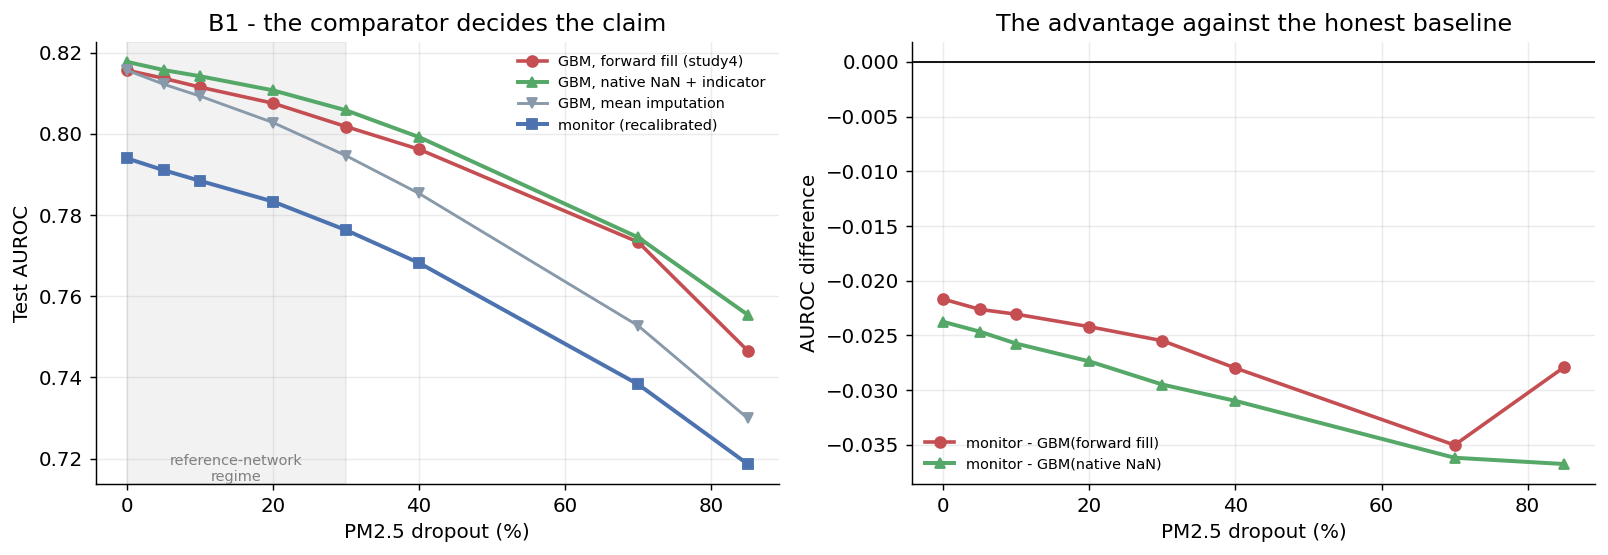


The green curve is the number that belongs in Table 2. If twin_minus_nan is
materially positive at 25 and 35 ug/m3, the robustness claim stands and you
report it against the native-NaN GBM. If it is near zero or negative, the
honest claim becomes parity with principled missing-data handling, plus the
calibration, belief-entropy and attribution the GBM does not provide.
Do not report twin_minus_ff as the headline: forward fill is a handicapped
comparator because HistGradientBoostingClassifier handles NaN natively.



In [7]:
fig,ax=plt.subplots(1,2,figsize=(12.5,4.4))
xp=[p*100 for p in R.dropout]
ax[0].plot(xp,R.gbm_ff,"-o",color="#C44E52",lw=2.0,label="GBM, forward fill (study4)")
ax[0].plot(xp,R.gbm_nan,"-^",color="#55A868",lw=2.2,label="GBM, native NaN + indicator")
ax[0].plot(xp,R.gbm_mean,"-v",color="#8899AA",lw=1.6,label="GBM, mean imputation")
ax[0].plot(xp,R.twin,"-s",color="#4C72B0",lw=2.2,label="monitor (recalibrated)")
ax[0].axvspan(0,30,color="grey",alpha=.10)
ax[0].annotate("reference-network\nregime",(15,ax[0].get_ylim()[0]),fontsize=8,ha="center",va="bottom",color="grey")
ax[0].set_xlabel("PM2.5 dropout (%)"); ax[0].set_ylabel("Test AUROC")
ax[0].set_title("B1 - the comparator decides the claim"); ax[0].legend(frameon=False,fontsize=8)
ax[1].axhline(0,color="k",lw=1)
ax[1].plot(xp,R.twin_minus_ff,"-o",color="#C44E52",lw=2.0,label="monitor - GBM(forward fill)")
ax[1].plot(xp,R.twin_minus_nan,"-^",color="#55A868",lw=2.2,label="monitor - GBM(native NaN)")
ax[1].set_xlabel("PM2.5 dropout (%)"); ax[1].set_ylabel("AUROC difference")
ax[1].set_title("The advantage against the honest baseline"); ax[1].legend(frameon=False,fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"fig1_missing_data_variants.png",bbox_inches="tight"); plt.show()

print("""
The green curve is the number that belongs in Table 2. If twin_minus_nan is
materially positive at 25 and 35 ug/m3, the robustness claim stands and you
report it against the native-NaN GBM. If it is near zero or negative, the
honest claim becomes parity with principled missing-data handling, plus the
calibration, belief-entropy and attribution the GBM does not provide.
Do not report twin_minus_ff as the headline: forward fill is a handicapped
comparator because HistGradientBoostingClassifier handles NaN natively.
""")